# U.S. Presidential Election County-Level Analysis
### Group Project — AI & Python Course
**Names**: Kari Zhou, Tavishi Kapoor, Bryana Freire, Navya Agarwal


**Student IDs:** 2581448, 2737234, 2625126, 2740890

## Introduction

The United States presidential election is decided not by  an Electoral College system in which each state awards its vote based on the state's majority vote. Because different counties within a state vary enormously in population size, a relatively small number of high-population counties often cast the majority of a state's total votes, making them disproportionately important in shaping the final result. Understanding which counties are most influential, and which political party tends to win them, can be meaningful in helping derive  how political geography drives election outcomes.

This project analyzes county-level presidential election results to answer four main questions: (1) Which counties are most influential in each state, measured by their share of total state votes? (2) Which political party wins those top counties? (3) Do top-county party preferences align with the overall state outcome? (4) How does county influence vary across different election results? This helps us answer our main question:
#### Does a specific party winning in a county increase its chances of winning in bigger elections (Senate, Governor, Presidential)?

Our analysis finds that **Preferences to political parties in counties and districts doesn't always result in aligned preference to a specific political party in presidential electioins.**


---
**Structure of this notebook:**
1. Data Description & Import
2. Data Merging & Cleaning
3. Results & Analysis
4. Discussion

## Section 1

### Data Description & Import

In [21]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

We use four datasets from the 2020 U.S. general election. 
The primary datasets are: `president_county_candidate.csv`, `senate_county_candidate.csv`, `governors_county_candidate.csv`, and `house_candidate.csv`

In [22]:
pres   = pd.read_csv('4-US_Election_2020/president_county_candidate.csv')
senate = pd.read_csv('4-US_Election_2020/senate_county_candidate.csv')
gov    = pd.read_csv('4-US_Election_2020/governors_county_candidate.csv')
house  = pd.read_csv('4-US_Election_2020/house_candidate.csv')

The "president_county_condidate.csv" shows how one row per candidate per county, covering 51 states/territories. Each row records the state, county name, candidate name, party affiliation, total votes received, and whether the candidate won that county. 

The dataset on gubernatorial elections (governors) includes all of the state’s counties, with each county’s election results reported separately. The election results include the candidate vote totals and their party affiliation, which allows us to analyze where votes have been cast and which of those have the largest impact on statewide elections.

The dataset on house candidate elections includes the number of votes received by candidates representing each district. The election results include the candidate vote totals and their party affiliation, which allows us to analyze the vote shares of each candidate/party within and across distrcits. 

The dataset on Senate elections includes results from 34 states, covering 2,426 counties, with each county's election results reported separately. The results span both major parties (Democratic and Republican) and a range of third parties including Libertarian, Independent, and Green. This structure allows us to analyse which counties carry the most influence over statewide outcomes and how third-party performance at the county level relates to broader election results.

## Section 2

### Data Merging and Cleaning

In [23]:
pres   = pd.read_csv('4-US_Election_2020/president_county_candidate.csv')
senate = pd.read_csv('4-US_Election_2020/senate_county_candidate.csv')
gov    = pd.read_csv('4-US_Election_2020/governors_county_candidate.csv')
house  = pd.read_csv('4-US_Election_2020/house_candidate.csv')

In [24]:
senate_state = senate.groupby(['state', 'party'])['total_votes'].sum().reset_index()

pres_merged = pd.merge(pres, senate_state, on='state', how='left', suffixes=('', '_senate'))
pres_merged.head()

,state,county,candidate,party,total_votes,won,party_senate,total_votes_senate
0,Delaware,Kent County,Joe Biden,DEM,44552,True,DEM,56137.0
1,Delaware,Kent County,Joe Biden,DEM,44552,True,IPD,7833.0
2,Delaware,Kent County,Joe Biden,DEM,44552,True,LIB,5244.0
3,Delaware,Kent County,Joe Biden,DEM,44552,True,REP,118652.0
4,Delaware,Kent County,Donald Trump,REP,41009,False,DEM,56137.0


This merge tells us the total number of votes per party per state which tells us the prevailing parties across states. 
Next, we merge this dataset with the presidential candidate dataset on the `state` column. This allows for the president winners to also be compared to the parties and those that won at a senate level.

In [25]:
major_parties = ['DEM', 'REP']

def big_parties(party):
    if party in major_parties:
        return party
    else:
        return 'OTH'
    
pres_merged['party'] = pres_merged['party'].apply(big_parties)


This helps simplify the data to only look at the bigger dual party system which dominates election results to keep analysis simple. 

In [26]:
state_totals = pres_merged.groupby('state')['total_votes'].sum().reset_index()

county_totals = pres_merged.groupby(['state', 'county'])['total_votes'].sum().reset_index()

merged = pd.merge(county_totals, state_totals, on='state', suffixes=('_county', '_state'))

merged['vote_share'] = (merged['total_votes_county'] / merged['total_votes_state']).round(2)

top = merged.sort_values('vote_share', ascending=False)
top10 = top.head(10)
top10

,state,county,total_votes_county,total_votes_state,vote_share
2747,Nevada,Clark County,972510,1405376,0.69
726,Hawaii,Honolulu County,382114,574469,0.67
114,Arizona,Maricopa County,6208425,10161978,0.61
489,Delaware,New Castle County,1150532,2016040,0.57
4053,Utah,Salt Lake County,541175,1488289,0.36
3020,New Mexico,Bernalillo County,952770,2771895,0.34
788,Illinois,Cook County,13928394,43293006,0.32
729,Idaho,Ada County,1037556,3472424,0.30
4460,Washington,King County,1210507,4087631,0.30
2679,Nebraska,Douglas County,829620,2869137,0.29


This is an important table. First, it finds the total number of votes in each state, following which is finds the total in each county. Next, it merges the two datasets to show a table with the total votes in each county in each state. Then, a new column is added known as "vote_share" which essentially shows the ratio of total shares in a state made up by a particular county, following which, sorting them in ascending order and displaying the first 5, allow for the top 5 most influential counties in each state to be identified. 

## Section 3

### Results and Analysis


#### **Presidential election**

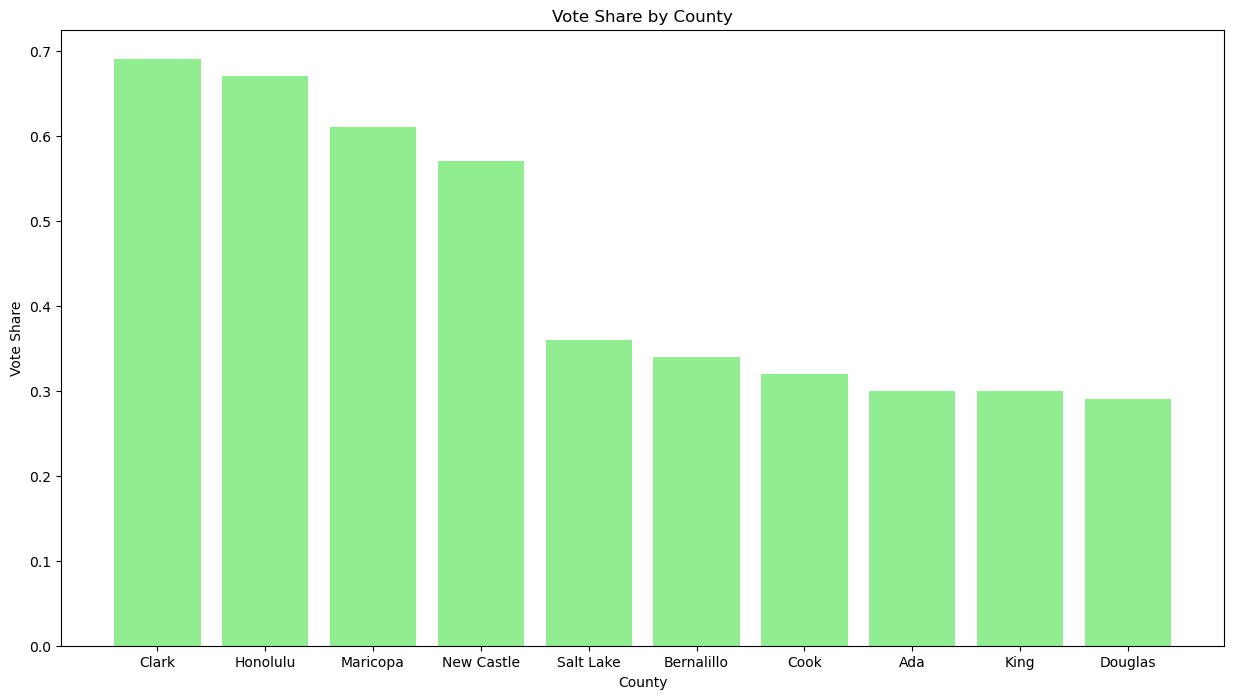

In [27]:
y = np.array(top10["county"])
z = []

for x in y:
    if "County" in x:
        a = len(x)
        b = a - 7
        new = x[:b]
        z.append(new)

plt.figure(figsize=(15, 8))        
plt.bar(x = z, height = top10["vote_share"], color = "lightgreen")
plt.title("Vote Share by County")
plt.xlabel("County")
plt.ylabel("Vote Share")
plt.show()


A visualisation of the votershare across counties. 

In [28]:
winners = pres_merged[pres_merged["won"] == True]

top_winners = pd.merge(winners, top10[["state", "county"]], on = ["state", "county"])

new_party = []
for x in (top_winners["party"]):
    if x == "DEM":
        y = 1
        new_party.append(y)
    else:
        f = 0
        new_party.append(f)
    
top_winners["count"] = new_party

percent_dem = (top_winners["count"].sum() / top_winners.shape[0])*100
print((percent_dem).round(2))

85.19


The democrats won the 2020 presidential election which tells us that more than 80% of the counties considered influential voted democratic. Now to check if this is consistent with the outcome for state elections by looking at the values for how these states affected the governor elections:


In [29]:
winners_gov = gov[gov["won"] == True]

state_party_votes = winners_gov.groupby(['state', 'party'])['votes'].sum()
state_party_votes.reset_index().head()

,state,party,votes
0,Delaware,DEM,236030
1,Delaware,REP,68435
2,Indiana,DEM,348860
3,Indiana,REP,1434873
4,Missouri,DEM,666952


In [30]:
dem = winners_gov[winners_gov['party'] == 'DEM']

check_winner = (dem["votes"].sum() / winners_gov["votes"].sum())*100
print(check_winner.round(2))

40.4


This shows that while, the democrats won the presidential election, they did not win a lot of the state elections during the governor's elections. However, 

In [31]:
top_winners_gov = pd.merge(winners_gov, top10[["state", "county"]], on = ["state", "county"])

new_party = []
for x in (top_winners_gov["party"]):
    if x == "DEM":
        y = 1
        new_party.append(y)
    else:
        f = 0
        new_party.append(f)
    
top_winners_gov["count"] = new_party

percent_dem_gov = (top_winners_gov["count"].sum() / top_winners_gov.shape[0])*100
print((percent_dem_gov).round(2))

66.67


This shows that of all the counties that were previously determined to be most influential, and the ones that were involved in the governor's elections, they still made up 2/3rds of the overall democratic vote. This is a more accurate determinant of how influential these counties can be since, even though only 1/3rd of them were included in the governor elections. 


#### **Governors election** 

##### **Question 1** Which counties are the most influential in each state's gubernatorial election based on their share of total votes?

In [32]:
## import data to make sure no overlaps in variable name
governors_county_candidate = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")
governors_county = pd.read_csv("4-US_Election_2020/governors_county.csv")
governors_state = pd.read_csv("4-US_Election_2020/governors_state.csv")

president_county_candidate = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
president_county = pd.read_csv("4-US_Election_2020/president_county.csv")
president_state = pd.read_csv("4-US_Election_2020/president_state.csv")

In [33]:
county_votes = (governors_county
                .groupby(["state", "county"])
                .agg(total_votes=("total_votes", "max"))
                .reset_index())

state_votes = governors_state.copy()
df = county_votes.merge(state_votes, on="state")
df["vote_share"] = df["total_votes"] / df["votes"]

df_top = (df
          .sort_values(["state", "vote_share"], ascending=[True, False])
          .groupby("state")
          .head(5))

df_top_sorted = df_top.sort_values(
    by=["state", "vote_share"], 
    ascending=[True, False]
).reset_index(drop=True)

df_top_sorted[["state", "county", "vote_share"]]

,state,county,vote_share
0,Delaware,New Castle County,0.583866
1,Delaware,Sussex County,0.262572
2,Delaware,Kent County,0.176652
3,Indiana,Marion County,0.129405
4,Indiana,Lake County,0.072824
5,Indiana,Hamilton County,0.064230
6,Indiana,Allen County,0.055980
7,Indiana,St. Joseph County,0.038153
8,Missouri,St. Louis County,0.178087
9,Missouri,Jackson County,0.110898


##### We calculated each county's share of total votes within it's state to determine its level of influence in the gubernatorial election. Each county was ranked by it's total vote share, and then the top 5 counties in each state were chosen as being the most influential as they provide the larget amount of votes to the total election results for their state.

##### **Question 2:** Which political party tends to dominate in the most influential counties across each state?

In [34]:
state = governors_state

data = county_votes.merge(state, on="state")
data["share"] = data["total_votes"] / data["votes"]

top = (data
       .sort_values(["state", "share"], ascending=[True, False])
       .groupby("state")
       .head(5))

winners = governors_county_candidate[
    governors_county_candidate["won"] == True
]

top_party = top.merge(winners, on=["state", "county"])
top_party = top_party.rename(columns={"party_y": "party"})

top_party_sorted = (top_party
                    .sort_values(["state", "share"], ascending=[True, False])
                    .reset_index(drop=True))

top_party_sorted[["state", "county", "party"]]

,state,county,party
0,Delaware,New Castle County,DEM
1,Delaware,Sussex County,REP
2,Delaware,Kent County,DEM
3,Indiana,Marion County,DEM
4,Indiana,Lake County,DEM
5,Indiana,Hamilton County,REP
6,Indiana,Allen County,REP
7,Indiana,St. Joseph County,REP
8,Missouri,St. Louis County,DEM
9,Missouri,Jackson County,DEM


#### After determing the top 5 most influential counties in each state's gubernatorial elections based on vote share, we then determined the political party of those counties. This allows us to see which party dominates in the most influential counties across each state.

##### **Question 3:** Do the political party preferences of the top 5 counties match the overall state election outcome?

In [35]:
top5_party = (top_party
              .groupby(["state", "party"])
              .size()
              .reset_index(name="count")
              .sort_values(["state", "count"], ascending=[True, False])
              .groupby("state")
              .head(1)
              .rename(columns={"party": "top5_party"}))

state_winner = (governors_county_candidate
                .groupby(["state", "party"])["votes"]
                .sum()
                .reset_index()
                .sort_values(["state", "votes"], ascending=[True, False])
                .groupby("state")
                .head(1)
                .rename(columns={"party": "state_winner"}))

result = top5_party.merge(state_winner[["state", "state_winner"]], on="state")
result["aligns"] = result["top5_party"] == result["state_winner"]

display(result)

,state,top5_party,count,state_winner,aligns
0,Delaware,DEM,2,DEM,True
1,Indiana,REP,3,REP,True
2,Missouri,DEM,3,REP,False
3,Montana,DEM,3,REP,False
4,New Hampshire,REP,5,REP,True
5,North Carolina,DEM,5,DEM,True
6,North Dakota,REP,5,REP,True
7,Utah,REP,5,REP,True
8,Vermont,REP,4,REP,True
9,Washington,DEM,4,DEM,True


#### We then compared the dominant political party in the top 5 most influential counties to the overall winner in the gubertorial elections for each state. We did this as it allowed us to determine whether the voting patterns in the deemed most impactful counties align witht the statewide results. Out of the 11 states listed, 9 states showed alignment, illustrating that the political party dominating the most influential counties is mostly reflected in the overall results.

##### **Concluding question for governors results:** Do the most influential counties in gubernatorial elections also reflect the outcome of presidential elections in each state? 

In [36]:
pres_winner = (president_county_candidate
               .groupby(["state", "party"])["total_votes"]
               .sum()
               .reset_index()
               .sort_values(["state", "total_votes"], ascending=[True, False])
               .groupby("state")
               .head(1)
               .rename(columns={"party": "pres_winner"}))

result = result.merge(pres_winner[["state", "pres_winner"]], on="state")
result["aligns_president"] = result["top5_party"] == result["pres_winner"]
result[["state", "top5_party", "state_winner", "pres_winner", "aligns", "aligns_president"]]

,state,top5_party,state_winner,pres_winner,aligns,aligns_president
0,Delaware,DEM,DEM,DEM,True,True
1,Indiana,REP,REP,REP,True,True
2,Missouri,DEM,REP,REP,False,False
3,Montana,DEM,REP,REP,False,False
4,New Hampshire,REP,REP,DEM,True,False
5,North Carolina,DEM,DEM,REP,True,False
6,North Dakota,REP,REP,REP,True,True
7,Utah,REP,REP,REP,True,True
8,Vermont,REP,REP,DEM,True,False
9,Washington,DEM,DEM,DEM,True,True


##### We further compared whether this earlier alignment reflected amongst the presidential elections.
While the top 5 counties did sway the gubertorial elections to their dominant political party preference, this wasn't true for the presidential elections. Matter of fact, there's no strong correlation between the most influential counties' political party preferences and the outcome of the presidental election. This could be explained through the differences in impacts counties have on a their local vs. national elections. Furthermore, this highlights the importance of the public vote on a local and state level compared to the electoral college system the presidential election employs. 

#### **Senate election results**

In [37]:
import matplotlib.ticker as mticker

df = pd.read_csv("senate_county_candidate.csv")
df = df[df["total_votes"] > 0].copy()


FileNotFoundError: [Errno 2] No such file or directory: 'senate_county_candidate.csv'


#### **Question 1**: Which counties are most influential in each state based on their share of total votes? (Top 5 per state)

In [ ]:
county_totals = df.groupby(["state", "county"])["total_votes"].sum().reset_index()
county_totals = county_totals.rename(columns={"total_votes": "county_total_votes"})

state_totals = df.groupby("state")["total_votes"].sum().reset_index()
state_totals = state_totals.rename(columns={"total_votes": "state_total_votes"})

county_totals = pd.merge(county_totals, state_totals, on = "state")
county_totals["vote_share_of_state"] = county_totals["county_total_votes"] / county_totals["state_total_votes"]

county_totals = county_totals.sort_values(["state", "vote_share_of_state"], ascending = [True, False])    #rank counties by vote share

top5_per_state = county_totals.groupby("state").head(5).reset_index(drop = True)

print("TOP 5 MOST INFLUENTIAL COUNTIES PER STATE (by vote share)")
(top5_per_state[["state", "county", "county_total_votes", "vote_share_of_state"]].round(3))

TOP 5 MOST INFLUENTIAL COUNTIES PER STATE (by vote share)


,state,county,county_total_votes,vote_share_of_state
0,Alabama,Jefferson County,134866,0.169
1,Alabama,Madison County,94901,0.119
2,Alabama,Mobile County,86349,0.108
3,Alabama,Tuscaloosa County,40594,0.051
4,Alabama,Shelby County,36842,0.046
...,...,...,...,...
163,Wyoming,Laramie County,15153,0.219
164,Wyoming,Natrona County,9210,0.133
165,Wyoming,Albany County,9038,0.131
166,Wyoming,Fremont County,5385,0.078


<font size = "5">
Plotting a Bar chart for "Top 5 Most Influential Counties in a Given State's Senate Race (2020)"

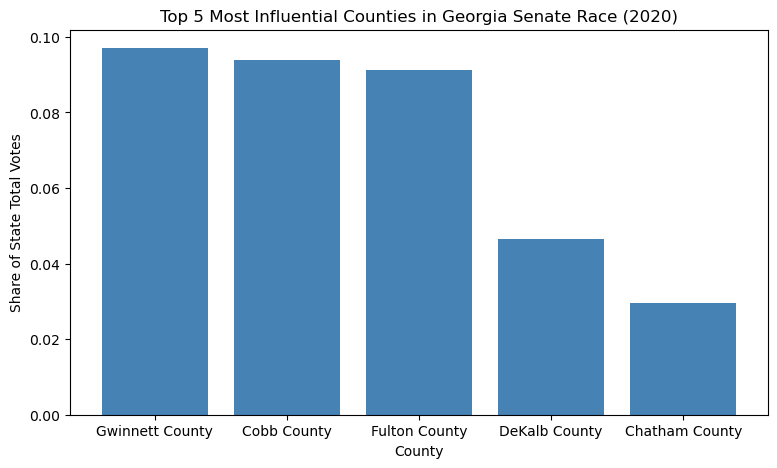

In [ ]:
example_state = "Georgia"       #Top 5 influential counties for a single state
state_data = top5_with_winner[top5_with_winner["state"] == example_state]

plt.figure(figsize = (9, 5))
plt.bar(state_data["county"], state_data["vote_share_of_state"], color = "steelblue")
plt.title("Top 5 Most Influential Counties in " + example_state + " Senate Race (2020)")
plt.xlabel("County")
plt.ylabel("Share of State Total Votes")
plt.show()

#### **Question 2** : Which political party wins the top 5 counties in each state?

In [ ]:
df_sorted = df.sort_values("total_votes", ascending=False)
county_winners = df_sorted.groupby(["state", "county"]).first().reset_index()
county_winners = county_winners[["state", "county", "candidate", "party", "total_votes"]]
county_winners = county_winners.rename(columns = {"total_votes": "winner_votes"})     #candidate with most votes

top5_with_winner = pd.merge(top5_per_state, county_winners, on = ["state", "county"])     #top 5 influential counties

print("PARTY WINNING THE TOP 5 INFLUENTIAL COUNTIES PER STATE")
(top5_with_winner[["state", "county", "vote_share_of_state", "party", "candidate"]].round(3))

PARTY WINNING THE TOP 5 INFLUENTIAL COUNTIES PER STATE


,state,county,vote_share_of_state,party,candidate
0,Alabama,Jefferson County,0.169,REP,Tommy Tuberville
1,Alabama,Madison County,0.119,DEM,Doug Jones
2,Alabama,Mobile County,0.108,DEM,Doug Jones
3,Alabama,Tuscaloosa County,0.051,DEM,Doug Jones
4,Alabama,Shelby County,0.046,DEM,Doug Jones
...,...,...,...,...,...
163,Wyoming,Laramie County,0.219,DEM,Merav Ben-David
164,Wyoming,Natrona County,0.133,DEM,Merav Ben-David
165,Wyoming,Albany County,0.131,DEM,Merav Ben-David
166,Wyoming,Fremont County,0.078,DEM,Merav Ben-David


#### **Question 3** Does the party winning the most influential counties match the overall state Senate winner?

In [ ]:
state_winner = df.groupby(["state", "candidate", "party"])["total_votes"].sum().reset_index()
state_winner = state_winner.sort_values("total_votes", ascending = False)
state_winner = state_winner.groupby("state").first().reset_index()
state_winner = state_winner.rename(columns = {"party": "state_winning_party", "total_votes": "state_winner_votes"})
state_winner = state_winner[["state", "state_winning_party"]]       #candidate with most total votes statewide

top5_party_count = top5_with_winner.groupby(["state", "party"])["county"].count().reset_index()
top5_party_count = top5_party_count.rename(columns = {"county": "counties_won"})
top5_party_count = top5_party_count.sort_values("counties_won", ascending = False)
dominant_party = top5_party_count.groupby("state").first().reset_index()
dominant_party = dominant_party.rename(columns = {"party": "top5_dominant_party"})
dominant_party = dominant_party[["state", "top5_dominant_party"]]       #most common winning party among top 5 counties per state

alignment = dominant_party.merge(state_winner, on = "state")
alignment["aligned"] = alignment["top5_dominant_party"] == alignment["state_winning_party"]     #compare

print("DO TOP 5 COUNTIES ALIGN WITH STATE SENATE OUTCOME?")
print(alignment)

aligned_count = alignment["aligned"].sum()
print("\nStates where top 5 counties aligned with state outcome:", aligned_count, "out of", len(alignment))

DO TOP 5 COUNTIES ALIGN WITH STATE SENATE OUTCOME?
             state top5_dominant_party state_winning_party  aligned
0          Alabama                 DEM                 DEM     True
1           Alaska                 REP                 DEM    False
2          Arizona                 DEM                 REP    False
3         Arkansas                 LIB                 LIB     True
4         Colorado                 REP                 REP     True
5         Delaware                 REP                 REP     True
6          Georgia                 REP                 REP     True
7            Idaho                 DEM                 DEM     True
8         Illinois                 REP                 REP     True
9             Iowa                 REP                 DEM    False
10          Kansas                 REP                 DEM    False
11        Kentucky                 DEM                 DEM     True
12       Louisiana                 DEM                 DEM     Tr

<font size = "5">
Plotting a Bar chart for "Do Top 5 Counties Predict the State Senate Winner?"

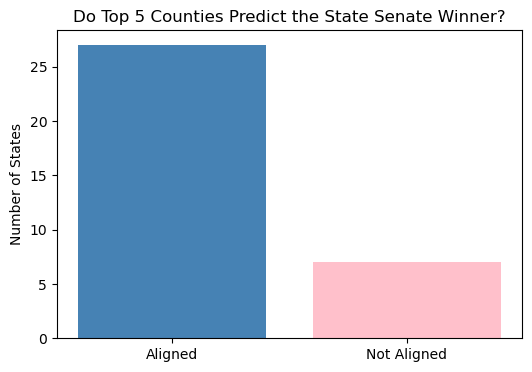

In [ ]:
aligned_counts = alignment["aligned"].value_counts()        #how many states aligned vs didn't

plt.figure(figsize = (6, 4))
plt.bar(["Aligned", "Not Aligned"], [aligned_counts.get(True, 0), aligned_counts.get(False, 0)], color = ["steelblue", "pink"])
plt.title("Do Top 5 Counties Predict the State Senate Winner?")
plt.ylabel("Number of States")
plt.show()

#### **Question 4** Are counties with high third-party Senate votes more or less likely to also have high third-party presidential votes?

In [ ]:
major_parties = ["DEM", "REP"]

third_party_votes = []
major_party_votes = []

for i in range(len(df)):
    row = df.iloc[i]
    if row["party"] in major_parties:
        major_party_votes.append(row["total_votes"])
        third_party_votes.append(0)
    else:
        third_party_votes.append(row["total_votes"])
        major_party_votes.append(0)

df["is_third_party_votes"] = third_party_votes
df["is_major_party_votes"] = major_party_votes

county_third_party = df.groupby(["state", "county"])["is_third_party_votes"].sum().reset_index()
county_third_party = county_third_party.rename(columns = {"is_third_party_votes": "third_party_total"})

county_third_party = pd.merge(county_third_party, county_totals[["state", "county", "county_total_votes"]], on = ["state", "county"])
county_third_party["third_party_share"] = county_third_party["third_party_total"] / county_third_party["county_total_votes"]

county_third_party = county_third_party.sort_values("third_party_share", ascending = False)

print("COUNTIES WITH HIGHEST THIRD-PARTY SENATE VOTE SHARE")
(county_third_party.head(20).round(3))

COUNTIES WITH HIGHEST THIRD-PARTY SENATE VOTE SHARE


,state,county,third_party_total,county_total_votes,third_party_share
190,Arkansas,Stone County,1209,1209,1.0
172,Arkansas,Newton County,728,728,1.0
160,Arkansas,Lee County,1135,1135,1.0
161,Arkansas,Lincoln County,893,893,1.0
162,Arkansas,Little River County,1137,1137,1.0
163,Arkansas,Logan County,1654,1654,1.0
164,Arkansas,Lonoke County,6887,6887,1.0
165,Arkansas,Madison County,1582,1582,1.0
138,Arkansas,Crawford County,5216,5216,1.0
137,Arkansas,Craighead County,11588,11588,1.0



##### Plotting a Bar chart for "Third-Party Senate Vote Share by County (2020)"

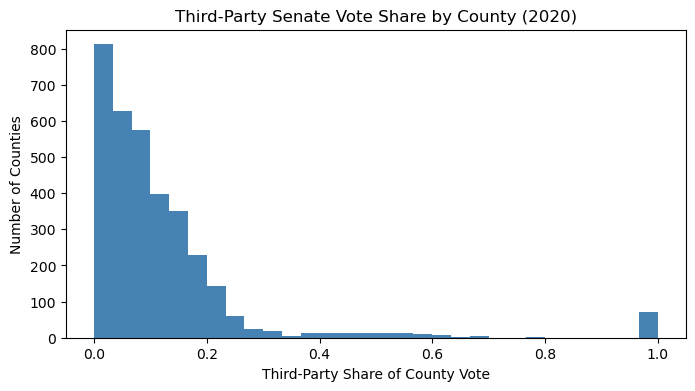

In [ ]:
plt.figure(figsize=(8, 4))      #Distribution of third-party vote share across counties
plt.hist(county_third_party["third_party_share"], bins = 30, color = "steelblue")
plt.title("Third-Party Senate Vote Share by County (2020)")
plt.xlabel("Third-Party Share of County Vote")
plt.ylabel("Number of Counties")
plt.show()

In [ ]:
print("Key DataFrames:")
print("county_totals — vote share of state per county")
print("top5_per_state — top 5 influential counties per state")
print("top5_with_winner — top 5 counties with their winning party")
print("alignment — whether top 5 counties predicted state outcome")
print("county_third_party — third-party vote share per county (for merging)")

Key DataFrames:
county_totals — vote share of state per county
top5_per_state — top 5 influential counties per state
top5_with_winner — top 5 counties with their winning party
alignment — whether top 5 counties predicted state outcome
county_third_party — third-party vote share per county (for merging)


<font size = "5">
Plotting a Bar chart for "Do Top 5 Counties Predict the State Senate Winner?"

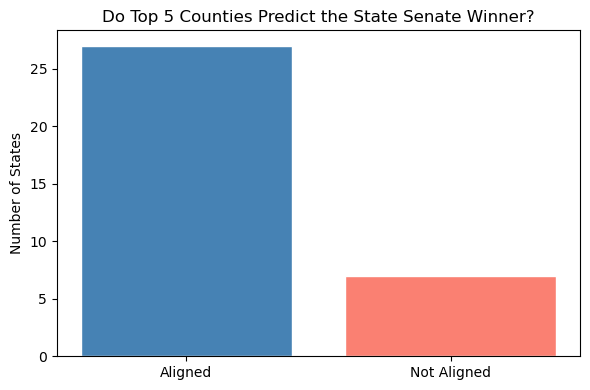

In [ ]:
aligned_counts = alignment["aligned"].value_counts()        #how many states aligned vs didn't

plt.figure(figsize=(6, 4))
plt.bar(["Aligned", "Not Aligned"], [aligned_counts.get(True, 0), aligned_counts.get(False, 0)],
        color=["steelblue", "salmon"], edgecolor="white")
plt.title("Do Top 5 Counties Predict the State Senate Winner?")
plt.ylabel("Number of States")
plt.tight_layout()
plt.savefig("senate_alignment.png", dpi=150)
plt.show()

<font size = "5">
Plotting a Bar chart for "Third-Party Senate Vote Share by County (2020)"

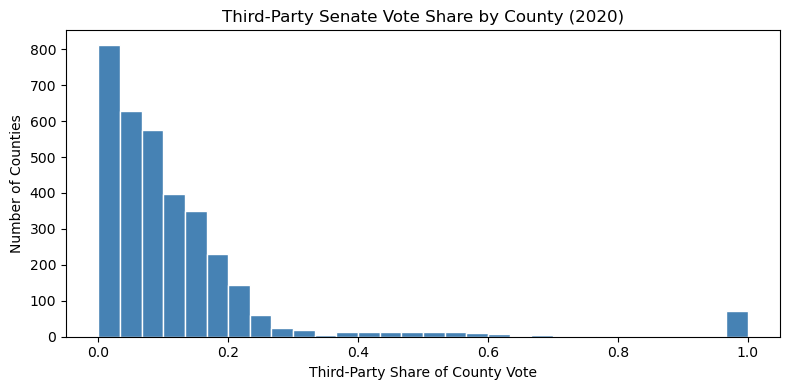

In [ ]:
plt.figure(figsize=(8, 4))      #Distribution of third-party vote share across counties
plt.hist(county_third_party["third_party_share"], bins=30, color="steelblue", edgecolor="white")
plt.title("Third-Party Senate Vote Share by County (2020)")
plt.xlabel("Third-Party Share of County Vote")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.savefig("senate_third_party_share.png", dpi=150)
plt.show()

In [ ]:
print("Key DataFrames:")
print("  county_totals        — vote share of state per county")
print("  top5_per_state       — top 5 influential counties per state")
print("  top5_with_winner     — top 5 counties with their winning party")
print("  alignment            — whether top 5 counties predicted state outcome")
print("  county_third_party   — third-party vote share per county (for merging)")

Key DataFrames:
  county_totals        — vote share of state per county
  top5_per_state       — top 5 influential counties per state
  top5_with_winner     — top 5 counties with their winning party
  alignment            — whether top 5 counties predicted state outcome
  county_third_party   — third-party vote share per county (for merging)


#### **House elections**
##### 1. Data cleaning and organization

In [ ]:
# reading in files
house_candidate = pd.read_csv("house_candidate.csv")
house_state = pd.read_csv("house_state.csv")
# calculate the total number of votes in each district. 
county_votes = (house_candidate
                .groupby(["district"])
                .agg(overall_votes=("total_votes", "sum"))
                .reset_index())
sum_values = county_votes.copy() 

house_candidate.merge(sum_values, how = 'left', on = 'district') # merge back to the house candidate df
house_candidate = house_candidate.merge(sum_values, how = 'left', on='district') # merge back to the house candidate df
 # calculate percentage of votes for each party. 
house_candidate['percentage'] = house_candidate['total_votes']/house_candidate['overall_votes']

In [ ]:
house_candidate = house_candidate[house_candidate['district'] != "United States’s 0th district"]
house_candidate = house_candidate.sort_values(by = "total_votes", ascending=False) # order by the number of votes received by each candidate. 
# only keep top two candidates to calculate the margin of victory. 
candidates = house_candidate.groupby(["district"]).head(2)
# rank by district
candidates.sort_values(by = "district")
candidates = candidates.dropna() # drop NA rows
candidates

,district,candidate,party,total_votes,won,overall_votes,percentage
969,Washington’s 7th district,Pramila Jayapal,DEM,387109,True,466462,0.829883
690,Oregon’s 3rd district,Earl Blumenauer,DEM,343574,True,469885,0.731187
704,Pennsylvania’s 3rd district,Dwight Evans,DEM,341708,True,375379,0.910301
623,North Carolina’s 12th district,Alma Adams,DEM,341457,True,341457,1.000000
415,Montana at large,Matt Rosendale,REP,339169,True,601509,0.563864
...,...,...,...,...,...,...,...
389,Mississippi’s 4th district,Write-ins,WRI,8670,False,264641,0.032761
1022,Alabama’s 6th district,Write-ins,WRI,8101,False,282261,0.028700
8,Florida’s 2nd district,Write-ins,WRI,6662,False,311999,0.021353
288,Massachusetts’s 3rd district,Write-ins,WRI,6643,False,293539,0.022631


##### 2. **Question 1** Do the top 5 district political party preferences align with their presidential election outcomes? **What are each party's top 5 supporters?** 




In [ ]:
# for DEM, filter for the top 5 districts. 
print(candidates.query("party == 'DEM'").sort_values(by="percentage", ascending=False).head(5)[['district', 'party', 'total_votes','percentage', 'won']])

                            district party  total_votes  percentage   won
1023          Alabama’s 7th district   DEM       225742    1.000000  True
623   North Carolina’s 12th district   DEM       341457    1.000000  True
772         Tennessee’s 5th district   DEM       252155    1.000000  True
510          New York’s 5th district   DEM       229125    0.993263  True
287     Massachusetts’s 3rd district   DEM       286896    0.977369  True


In [ ]:
print(candidates.query("party == 'REP'").sort_values(by="percentage", ascending=False).head(5)[['district', 'party', 'total_votes','percentage', 'won']])

                     district party  total_votes  percentage   won
1050  Arkansas’s 1st district   REP       237596    1.000000  True
946   Virginia’s 9th district   REP       271851    1.000000  True
1020   Alabama’s 5th district   REP       253094    1.000000  True
7      Florida’s 2nd district   REP       305337    0.978647  True
1021   Alabama’s 6th district   REP       274160    0.971300  True


In [ ]:
print(candidates.query("party == 'IND'").sort_values(by="percentage", ascending=False).head(5)[['district', 'party', 'total_votes','percentage', 'won']])

                         district party  total_votes  percentage    won
302  Massachusetts’s 8th district   IND        72060    0.186974  False
737   Rhode Island’s 1st district   IND        35457    0.159496  False
299  Massachusetts’s 7th district   IND        38675    0.125304  False


The top 5 districts in support of the Democrats are from Tennessee, New Carolina, Alabama, New York, and Massacheusets. 
##### Take Tennessee's 5th district as an example, **would the election results for house candidates at district be indicative of their state election results for president in 2020**?

In [ ]:
president_county = pd.read_csv("president_county_candidate.csv")

president_county.head()
#calculate vote share in president election results. 
sum_prez = president_county.groupby(["county"])['total_votes'].sum()
sum_prez.name = 'sum_votes'
sum_prez
president_county = president_county.merge(sum_prez, how = 'left', on='county') # merge back to the house candidate df
president_county['percentage'] = president_county['total_votes']/president_county['sum_votes'] # calculate percentage of votes for each party. 
president_county

,state,county,candidate,party,total_votes,won,sum_votes,percentage
0,Delaware,Kent County,Joe Biden,DEM,44552,True,459329,0.096994
1,Delaware,Kent County,Donald Trump,REP,41009,False,459329,0.089280
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False,459329,0.002273
3,Delaware,Kent County,Howie Hawkins,GRN,420,False,459329,0.000914
4,Delaware,New Castle County,Joe Biden,DEM,195034,True,287633,0.678065
...,...,...,...,...,...,...,...,...
32172,Arizona,Maricopa County,Write-ins,WRI,1331,False,2069475,0.000643
32173,Arizona,Mohave County,Donald Trump,REP,78535,True,104705,0.750060
32174,Arizona,Mohave County,Joe Biden,DEM,24831,False,104705,0.237152
32175,Arizona,Mohave County,Jo Jorgensen,LIB,1302,False,104705,0.012435


In [ ]:
# for DEM, filter for the top 5 districts. 
print(candidates.query("party == 'DEM'").sort_values(by="percentage", ascending=False).head(5)[['district', 'party', 'total_votes','percentage', 'won']])

                            district party  total_votes  percentage   won
1023          Alabama’s 7th district   DEM       225742    1.000000  True
623   North Carolina’s 12th district   DEM       341457    1.000000  True
772         Tennessee’s 5th district   DEM       252155    1.000000  True
510          New York’s 5th district   DEM       229125    0.993263  True
287     Massachusetts’s 3rd district   DEM       286896    0.977369  True


##### As seen above, Tennessee's 5th district has a 100% vote for Democratic party house candidate in 2020. 
Davidson County, Lewis County, Marshall County, Maury County, Wilson County, and Williamson County are part of the Tennessee's 5th district.
 **For this district, is their politicial preference to a democrat house candidate reflected in their votes for presidential election?**

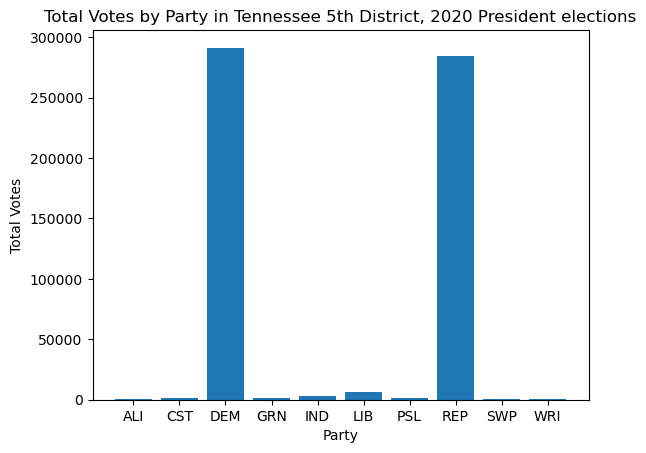

In [ ]:
tn5th = ['Davidson County', 'Lewis County', 'Marshall County','Maury County', 'Wilson County', 'Williamson County']
tennessee_5th = president_county[president_county['county'].isin(tn5th)]
tennessee_5th = tennessee_5th[tennessee_5th['state'] == 'Tennessee']
tennessee_5th.groupby('party')
tennessee_5th['sum_votes'].sum()
party_votes = tennessee_5th.groupby('party')['total_votes'].sum() # calculate the number of votes each party got, in Tennessee's 5th district. 

plt.bar(party_votes.index, party_votes.values)
plt.xlabel('Party')
plt.ylabel('Total Votes')
plt.title('Total Votes by Party in Tennessee 5th District, 2020 President elections')
plt.show()

**Answer** It does seem like democrat party has slightly higher advantage over republican, in the 5th District, where democrats re at advantage in house elections. 

Similarly, **Virgina's 9th district** has an absolute win for Republican house candidate in 2020. Bedford County, Bland County, B uchanan County, Carroll County, Craig County, Dickenson County, Floyd County. Franklin County, Giles County, Grayson County, Henry County, Lee County, Montgomery County, Patrick County, Pulaski County, Roanoke County, Russell County, Scott County, Smyth County, Tazewell County, Washington County, Wise County, Wythe County, and some independent cities are in this district.

 Here, we would impute the presidential election results for this district using the data for all counties. 

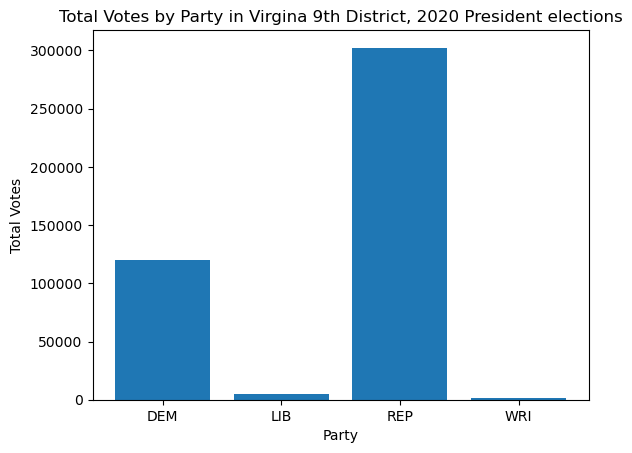

In [ ]:
VA9th = ['Bedford County', 'Bland County', 'Buchanan County', 'Carroll County', 'Craig County', 
         'Dickenson County', 'Floyd County', 'Franklin County', 'Giles County', 'Grayson County', 
         'Henry County', 'Lee County', 'Montgomery County', 'Patrick County', 'Pulaski County', 
         'Roanoke County', 'Russell County', 'Scott County', 'Smyth County', 'Tazewell County', 
         'Washington County', 'Wise County', 'Wythe County']
Virginia_9th = president_county[president_county['county'].isin(VA9th)]
Virginia_9th = Virginia_9th[Virginia_9th['state'] == 'Virginia']
Virginia_9th.groupby('party')
Virginia_9th['sum_votes'].sum()
party_votes = Virginia_9th.groupby('party')['total_votes'].sum() # calculate the number of votes each party got, in Virgina's 9th district. 

plt.bar(party_votes.index, party_votes.values)
plt.xlabel('Party')
plt.ylabel('Total Votes')
plt.title('Total Votes by Party in Virgina 9th District, 2020 President elections')
plt.show()

##### **Conclusion**:
Based on the comparison between these results, it seems like the political preference for house candidates does reflect in the presidential election results. Virginia's 9th District has a a stronger prefernece to Republicans than does Tennesse's 5th District to Democrats. 

##### Then, we were curious about the Margin of Victory (MOV) for house candidate elections in each district. 
##### **Question 2** Did specific party win with absolute competitiveness in the given district? How does the pattern reflect in the presidential elections for this district? 

In [ ]:
# transpose the table into wide format, based on winning situation
mov_candidates = candidates.pivot_table(
    index='district',
    columns='won',
    values='percentage'
)

mov_candidates = mov_candidates.rename(columns={False: 'loser_pct', True: 'winner_pct'})

# filter for absolute win:
abs_win = mov_candidates.loc[mov_candidates['winner_pct']==1]
abs_win['loser_pct']  = 0 # set loser_pct = 0
# merge back to original df, using update
mov_candidates.update(abs_win)

# calculate MOV
mov_candidates['MOV']= mov_candidates['winner_pct'] - mov_candidates['loser_pct']


# competitiveness using pd.cut
mov_candidates['competitiveness'] = pd.cut(
    mov_candidates['MOV'],
    bins=[0, 0.10, 0.20, 1.0],
    labels=['Competitive', 'Likely', 'Safe']
)

# filter for competitive district (top 3)
mov_candidates.query("competitiveness == 'Competitive'").sort_values(by='MOV', ascending=True).head(3)

/var/folders/2j/hm6b3scn7xd3xcb7y1cgbydm0000gn/T/ipykernel_12670/277414905.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abs_win['loser_pct']  = 0 # set loser_pct = 0


won,loser_pct,winner_pct,MOV,competitiveness
district,,,,
Iowa’s 2nd district,0.499992,0.500008,0.000015,Competitive
New York’s 22nd district,0.489664,0.489702,0.000038,Competitive
California’s 25th district,0.499509,0.500491,0.000982,Competitive


Iowa's 2nd district has a margin of victory as low as 0.0015%, and California's 25th district with 0.98%.  

##### Iowa's 2nd district

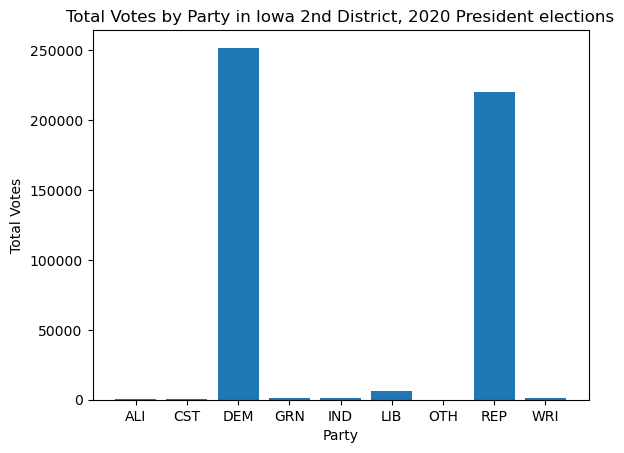

In [ ]:
IOWA2nd = [
    "Benton County",
    "Cedar County",
    "Clinton County",
    "Delaware County",
    "Dubuque County",
    "Iowa County",
    "Jackson County",
    "Johnson County",
    "Jones County",
    "Linn County",
    "Muscatine County",
    "Scott County",
    "Washington County"
]
Iowa_2nd = president_county[president_county['county'].isin(IOWA2nd)]
Iowa_2nd = Iowa_2nd[Iowa_2nd['state'] == 'Iowa']
Iowa_2nd.groupby('party')
Iowa_2nd['sum_votes'].sum()
party_votes = Iowa_2nd.groupby('party')['total_votes'].sum() # calculate the number of votes each party got, in Virgina's 9th district. 

plt.bar(party_votes.index, party_votes.values)
plt.xlabel('Party')
plt.ylabel('Total Votes')
plt.title('Total Votes by Party in Iowa 2nd District, 2020 President elections')
plt.show()

##### What about California's 25th District? 

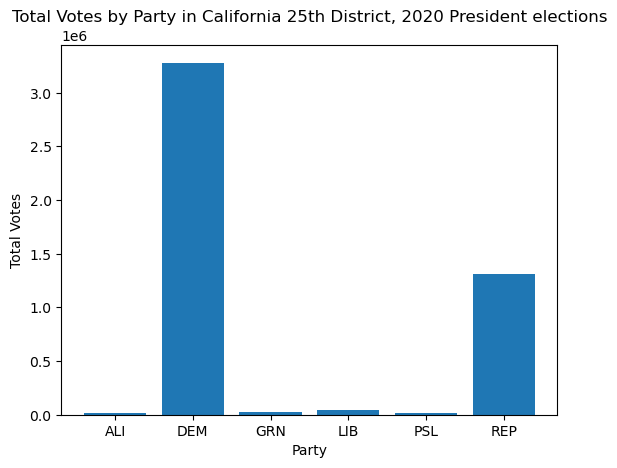

In [ ]:
california_25th_district_counties = [
    "Los Angeles County",
    "Ventura County"
]

california_25th = president_county[president_county['county'].isin(california_25th_district_counties)]
california_25th = california_25th[california_25th['state'] == 'California']
california_25th.groupby('party')
california_25th['sum_votes'].sum()
party_votes = california_25th.groupby('party')['total_votes'].sum() # calculate the number of votes each party got, in Virgina's 9th district. 

plt.bar(party_votes.index, party_votes.values)
plt.xlabel('Party')
plt.ylabel('Total Votes')
plt.title('Total Votes by Party in California 25th District, 2020 President elections')
plt.show()

##### **Conclusion**: 

For our analysis focusing on House Candidates, we can't easily draw a conclusion on how they reflect presidential election results. For house candidates with absolute wins in a certaind districts, people follow a similar trend in presidential elections as well. 
However, for those districts where the MOV for house candidates is really really low, people's vote for presidential election didn't seem to be also scorching. 

## Section 4

### Discussion

This analysis shows whether a small number of high-population counties can contribute disproportionately to total state vote counts. While, 85% of all the highly influential states voted democratic and the presidential election winner was democratic, the analysis comparision with governors shows a different result. Only 40% of the overall votes were democratic but, 66% of the influential counties included voted democratic whereas only, a third were in the governor elections this time. This shows that with the temporal differences in elections it is difficult to ascertain wether the larger presidential election is highly affected by smaller counties that may be influential at a more local level. Overall, while there can be small disproprtionalities, it is not large enough to ascertain a significant affect. 

**Preferences to political parties in counties and districts doesn't always result in aligned preference to a specific political party in presidential electioins.**